# Model Comparison: TF-IDF + Logistic Regression vs BERTweet

This notebook compares the performance of two different approaches for disaster tweet classification:
1. **TF-IDF + Logistic Regression** (Classical ML)
2. **BERTweet** (Transformer-based Deep Learning)

We'll evaluate both models on the same test set and compare:
- Performance metrics (Accuracy, Precision, Recall, F1)
- Inference speed
- Error analysis
- Model strengths and weaknesses

## 1. Setup and Imports

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import time
import warnings
warnings.filterwarnings('ignore')

# For better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

c:\Users\sonia\Desktop\master\master an 2\deep learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.6.0+cu124
CUDA available: True


## 2. Load Data and Models

In [ ]:
# Load the data using the same utility function
from utils import load_data

df, X_train, X_test, y_train, y_test = load_data("train_prepared.csv")

print(f"Total dataset size: {len(df)}")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts())

train distribution:
true:  41.020114942528735%
false: 58.97988505747126%

test distribution:
true:  41.020114942528735%
false: 58.97988505747126%
train distribution:
true:  41.020114942528735%
false: 58.97988505747126%

test distribution:
true:  41.020114942528735%
false: 58.97988505747126%
Total dataset size: 6960
Training set size: 5568
Test set size: 1392

Test set class distribution:
target
0    821
1    571
Name: count, dtype: int64


### 2.1 Load TF-IDF + Logistic Regression Model

In [4]:
tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')
lr_model = joblib.load('logistic_regression_model.pkl')

### 2.2 Load BERTweet Model

In [5]:
bert_model = AutoModelForSequenceClassification.from_pretrained('./final_bertweet_model')
bert_tokenizer = AutoTokenizer.from_pretrained('./final_bertweet_tokenizer_model')

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)
bert_model.eval()  # Set to evaluation mode

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (position_embeddings): Embedding(130, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

## 3. Make Predictions

### 3.1 TF-IDF + LR Predictions

In [6]:
start_time = time.time()

X_test_tfidf = tfidf_vectorizer.transform(X_test)
lr_predictions = lr_model.predict(X_test_tfidf)
lr_probabilities = lr_model.predict_proba(X_test_tfidf)[:, 1]

lr_inference_time = time.time() - start_time

print(f"✓ Predictions complete in {lr_inference_time:.4f} seconds")
print(f"  Average time per sample: {(lr_inference_time/len(X_test))*1000:.2f} ms")

✓ Predictions complete in 0.0362 seconds
  Average time per sample: 0.03 ms


### 3.2 BERTweet Predictions

In [7]:
# Make predictions with BERTweet using Trainer API
print("Making BERTweet predictions...")

from transformers import Trainer, TrainingArguments
from datasets import Dataset
from utils import compute_metrics

# Prepare test dataset in the same format as training
test_dataset = Dataset.from_dict({
    'text': X_test.tolist(),
    'label': y_test.tolist()
})

# Tokenize the test dataset
test_dataset = test_dataset.map(
    lambda x: bert_tokenizer(x["text"], padding='max_length', truncation=True, max_length=128), 
    batched=True
)

# Create a Trainer for prediction (no training)
trainer = Trainer(
    model=bert_model,
    compute_metrics=compute_metrics
)

# Make predictions and measure time
start_time = time.time()
predictions_output = trainer.predict(test_dataset)
bert_inference_time = time.time() - start_time

# Extract predictions and probabilities
logits = predictions_output.predictions
bert_probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]  # Probability of class 1
bert_predictions = np.argmax(logits, axis=1)

print(f"✓ Predictions complete in {bert_inference_time:.4f} seconds")
print(f"  Average time per sample: {(bert_inference_time/len(X_test))*1000:.2f} ms")

Making BERTweet predictions...


Map: 100%|██████████| 1392/1392 [00:00<00:00, 2168.92 examples/s]


✓ Predictions complete in 8.4223 seconds
  Average time per sample: 6.05 ms


## 4. Performance Comparison

### 4.1 Calculate Metrics

In [8]:
def calculate_metrics(y_true, y_pred, y_proba, model_name):
    """Calculate and return all metrics for a model"""
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC AUC': auc(*roc_curve(y_true, y_proba)[:2])
    }

# Calculate metrics for both models
lr_metrics = calculate_metrics(y_test, lr_predictions, lr_probabilities, 'TF-IDF + LR')
bert_metrics = calculate_metrics(y_test, bert_predictions, bert_probabilities, 'BERTweet')

# Create comparison dataframe
metrics_df = pd.DataFrame([lr_metrics, bert_metrics])
metrics_df = metrics_df.set_index('Model')

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(metrics_df.to_string())
print("="*70)


MODEL PERFORMANCE COMPARISON
             Accuracy  Precision    Recall  F1 Score   ROC AUC
Model                                                         
TF-IDF + LR  0.848420   0.832103  0.789842  0.810422  0.927312
BERTweet     0.824713   0.781411  0.795096  0.788194  0.890885


### 4.2 Performance Metrics Visualization

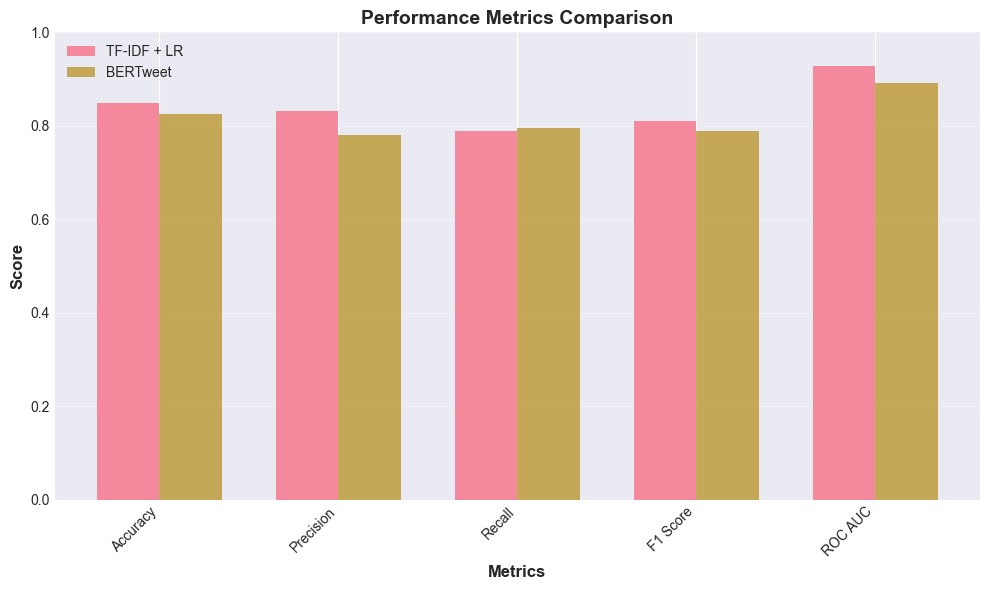

In [25]:
# Plot metrics comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

ax.bar(x - width/2, metrics_df.loc['TF-IDF + LR', metrics_to_plot], 
       width, label='TF-IDF + LR', alpha=0.8)
ax.bar(x + width/2, metrics_df.loc['BERTweet', metrics_to_plot], 
       width, label='BERTweet', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Confusion Matrices

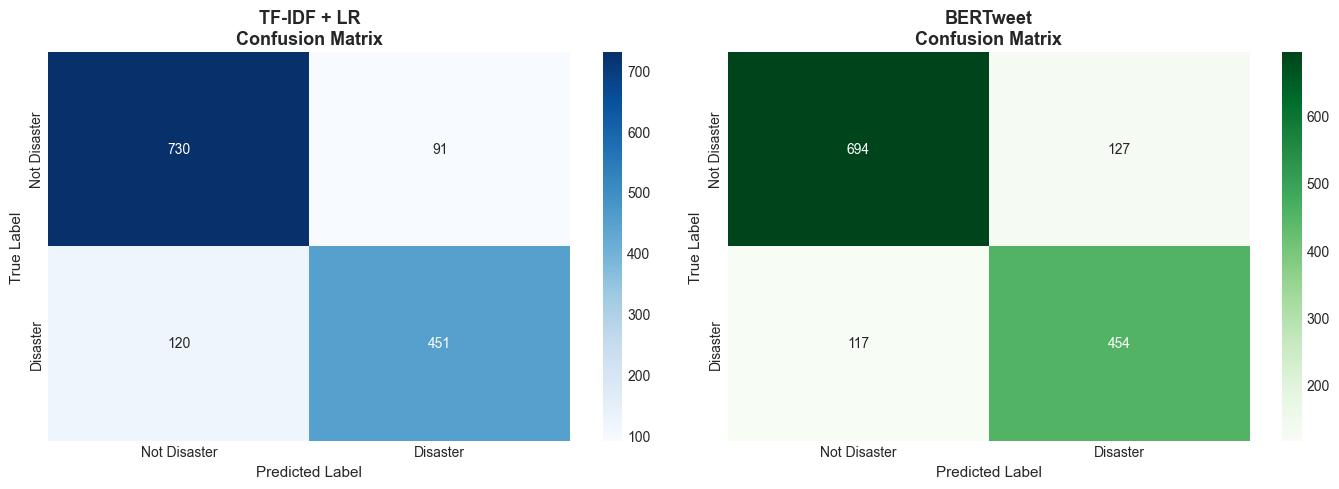

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TF-IDF + LR Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Disaster', 'Disaster'],
            yticklabels=['Not Disaster', 'Disaster'])
axes[0].set_title('TF-IDF + LR\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# BERTweet Confusion Matrix
cm_bert = confusion_matrix(y_test, bert_predictions)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Disaster', 'Disaster'],
            yticklabels=['Not Disaster', 'Disaster'])
axes[1].set_title('BERTweet\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

### 4.4 ROC Curves

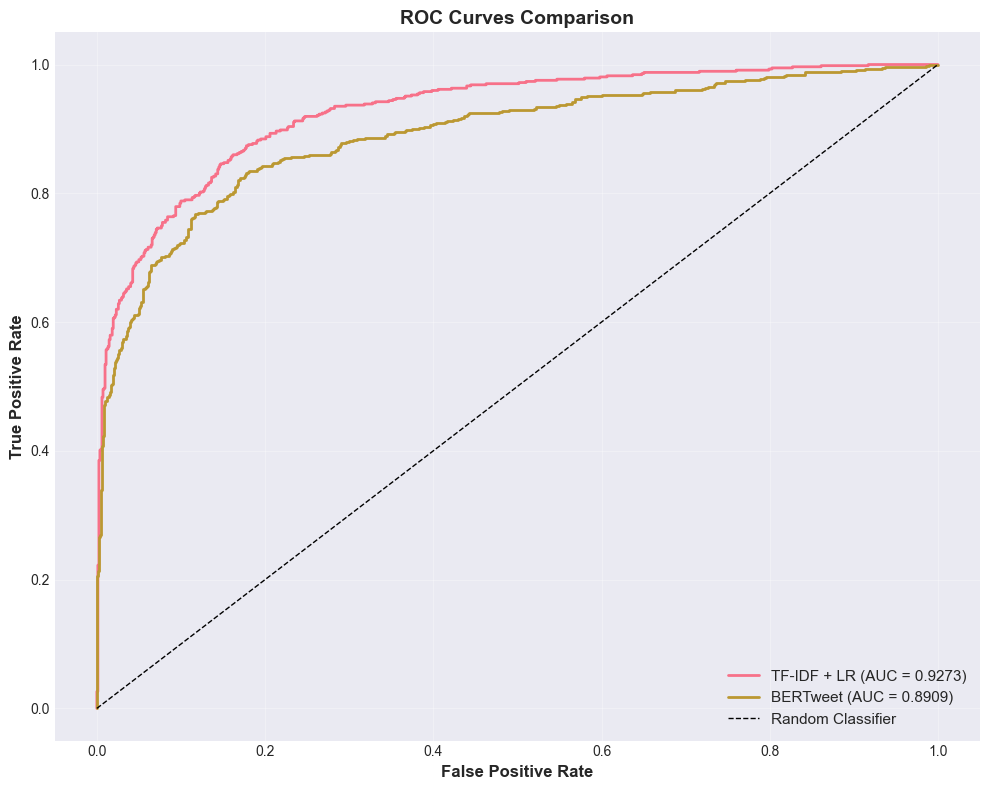

In [11]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probabilities)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_bert, tpr_bert, _ = roc_curve(y_test, bert_probabilities)
roc_auc_bert = auc(fpr_bert, tpr_bert)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, linewidth=2, 
         label=f'TF-IDF + LR (AUC = {roc_auc_lr:.4f})')
plt.plot(fpr_bert, tpr_bert, linewidth=2,
         label=f'BERTweet (AUC = {roc_auc_bert:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Precision-Recall Curves

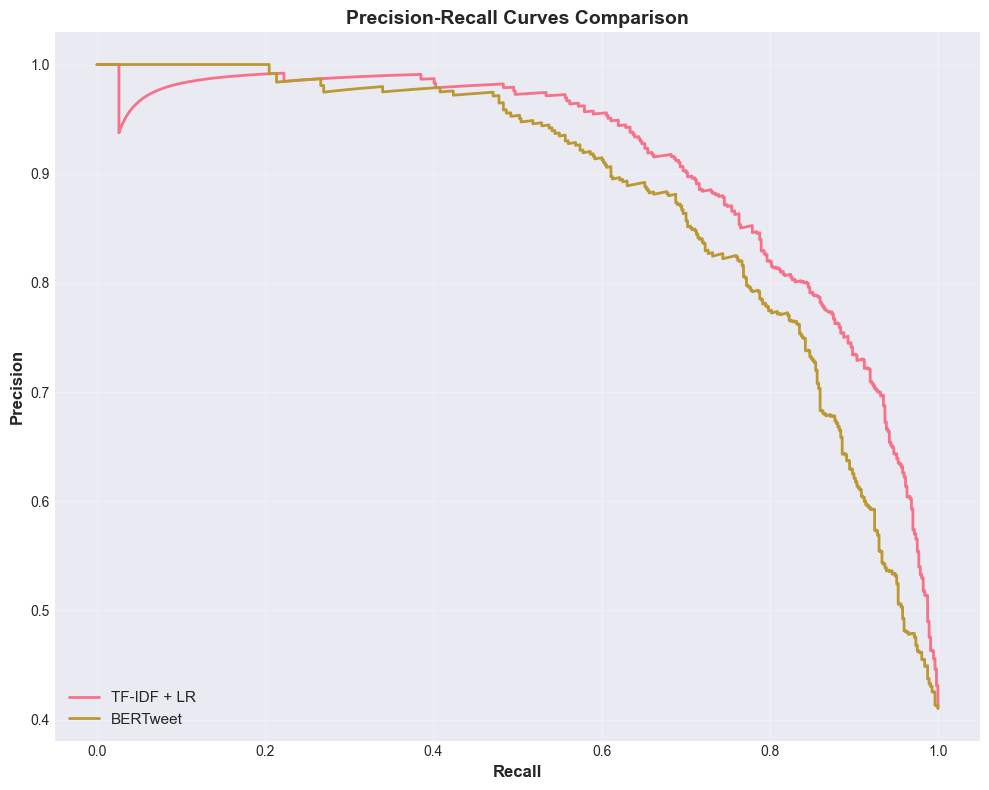

In [12]:
# Calculate Precision-Recall curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_probabilities)
precision_bert, recall_bert, _ = precision_recall_curve(y_test, bert_probabilities)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))
plt.plot(recall_lr, precision_lr, linewidth=2, label='TF-IDF + LR')
plt.plot(recall_bert, precision_bert, linewidth=2, label='BERTweet')

plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Error Analysis

### 6.1 Agreement Analysis

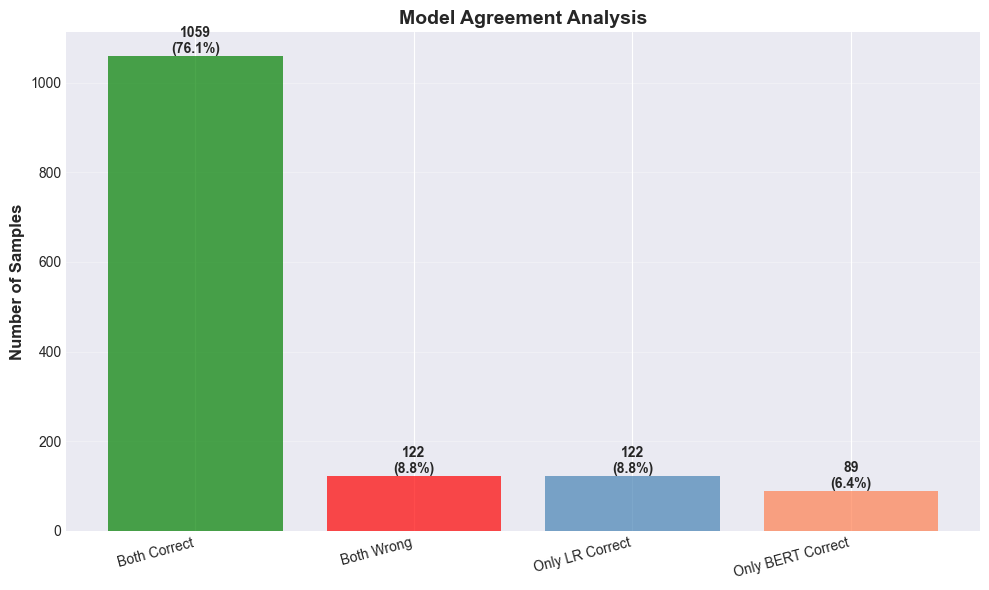

In [21]:
# Analyze where models agree and disagree
lr_correct = lr_predictions == y_test
bert_correct = bert_predictions == y_test

both_correct = lr_correct & bert_correct
both_wrong = ~lr_correct & ~bert_correct
only_lr_correct = lr_correct & ~bert_correct
only_bert_correct = ~lr_correct & bert_correct

agreement_stats = pd.DataFrame({
    'Category': ['Both Correct', 'Both Wrong', 'Only LR Correct', 'Only BERT Correct'],
    'Count': [
        both_correct.sum(),
        both_wrong.sum(),
        only_lr_correct.sum(),
        only_bert_correct.sum()
    ],
    'Percentage': [
        both_correct.sum()/len(y_test)*100,
        both_wrong.sum()/len(y_test)*100,
        only_lr_correct.sum()/len(y_test)*100,
        only_bert_correct.sum()/len(y_test)*100
    ]
})
# Visualize agreement
fig, ax = plt.subplots(figsize=(10, 6))
colors_map = {'Both Correct': 'green', 'Both Wrong': 'red', 
              'Only LR Correct': 'steelblue', 'Only BERT Correct': 'coral'}
colors = [colors_map[cat] for cat in agreement_stats['Category']]

bars = ax.bar(agreement_stats['Category'], agreement_stats['Count'], 
              color=colors, alpha=0.7)
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Model Agreement Analysis', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count, pct in zip(bars, agreement_stats['Count'], agreement_stats['Percentage']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 6.2 Confidence Analysis

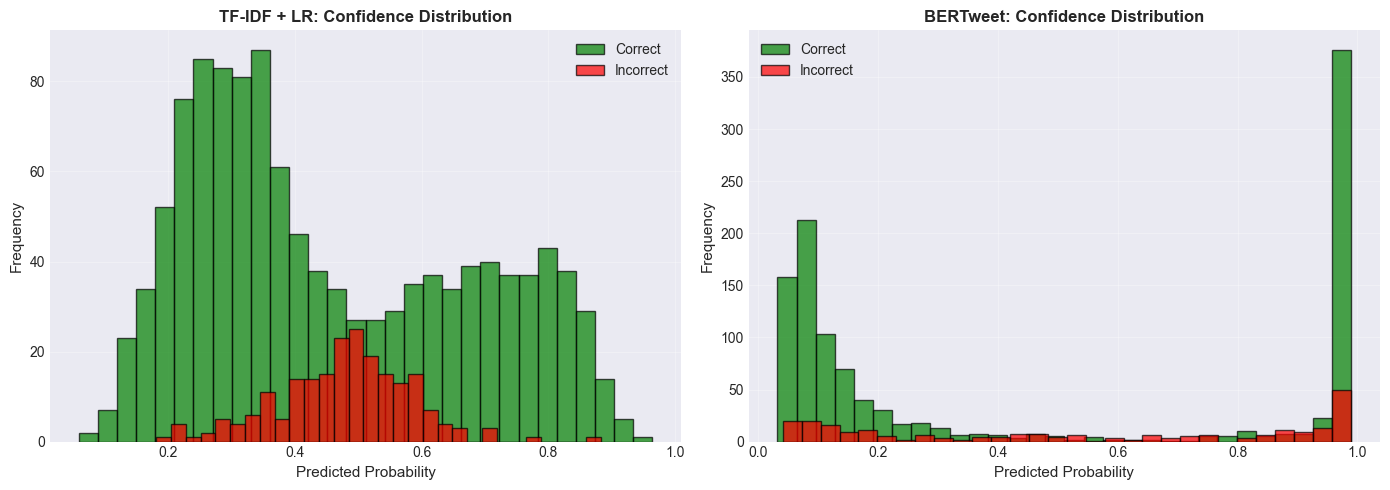

In [24]:
# Compare prediction confidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR confidence distribution
lr_correct_probs = lr_probabilities[lr_correct]
lr_incorrect_probs = lr_probabilities[~lr_correct]

axes[0].hist(lr_correct_probs, bins=30, alpha=0.7, color='green', 
             label='Correct', edgecolor='black')
axes[0].hist(lr_incorrect_probs, bins=30, alpha=0.7, color='red',
             label='Incorrect', edgecolor='black')
axes[0].set_xlabel('Predicted Probability', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('TF-IDF + LR: Confidence Distribution', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# BERT confidence distribution
bert_correct_probs = bert_probabilities[bert_correct]
bert_incorrect_probs = bert_probabilities[~bert_correct]

axes[1].hist(bert_correct_probs, bins=30, alpha=0.7, color='green',
             label='Correct', edgecolor='black')
axes[1].hist(bert_incorrect_probs, bins=30, alpha=0.7, color='red',
             label='Incorrect', edgecolor='black')
axes[1].set_xlabel('Predicted Probability', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('BERTweet: Confidence Distribution',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Save Comparison Results

In [18]:
# Save detailed results
results_df.to_csv('model_comparison_results.csv', index=False)
print("✓ Detailed results saved to 'model_comparison_results.csv'")

# Save metrics comparison
metrics_df.to_csv('metrics_comparison.csv')
print("✓ Metrics comparison saved to 'metrics_comparison.csv'")

# Save summary
with open('comparison_summary.txt', 'w') as f:
    f.write(summary)
print("✓ Summary saved to 'comparison_summary.txt'")

✓ Detailed results saved to 'model_comparison_results.csv'
✓ Metrics comparison saved to 'metrics_comparison.csv'
✓ Summary saved to 'comparison_summary.txt'
